In [1]:
import phoebe
from phoebe.features import ComponentFeature
from phoebe.parameters import FloatParameter, ParameterSet
from astropy import units as u
import numpy as np

b = phoebe.default_binary()
b.add_dataset('rv', compute_phases=phoebe.linspace(0,1,101))
b.set_value('irrad_method', 'none')

b.run_compute(model='no_features')


class DifferentialRotation(ComponentFeature):
    @classmethod
    def create_feature_parameters(self, feature, **kwargs):
        params = []
        params += [FloatParameter(qualifier='alpha',
                                  latexfmt=r'\alpha_\mathrm{{ {feature} }}',
                                  value=kwargs.get('alpha', 0.2),
                                  default_unit=u.dimensionless_unscaled,
                                  description='Differential rotation coefficient')]

        return ParameterSet(params), []
    
    @classmethod
    def parse_bundle(cls, b, feature_ps):
        t0 = b.get_value(qualifier='t0', context='system', unit=u.d, **_skip_filter_checks)
        feature_dict =  cls.parse_from_feature_ps(b, feature_ps,
                                                  ['alpha'])
        return dict(t0=t0, **feature_dict)

    def requires_remeshing(self):
        return False
    
    def modify_rvs(self, rvs, orbit_vel,
                   roche_coords, s=[0., 0., 1.], t=None):
        import numpy as np

        # NOTE: orbit_vel[2] (vw) is in opposite direction of rvs!
        rvs_rot = rvs + orbit_vel[2]

        r, colat, long = self.cartesian_to_spherical(roche_coords)
        # Reiners & Royer A&A 2004
        # alpha = 0.2 for solar
        # vel_rigid(colat) = vel_equator * sin(colat)
        # vel_diffrot(colat) = vel_equator * (1-alpha sin2 (colat))
        
        sin_colat = np.sin(colat)
        eps = 1e-12
        factor = (1 - self.kwargs['alpha'] * sin_colat**2) / np.where(np.abs(sin_colat) < eps, eps, sin_colat)
        
        return -orbit_vel[2] + rvs_rot * factor

b.add_feature(DifferentialRotation, component='primary', alpha=0.8, feature='sinusoidal_intensities')
b.add_dataset('mesh', compute_phases=phoebe.linspace(0,1,51), columns=['rvs*'])
b.run_compute(model='with_diff_rot')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 143.03it/s]


<ParameterSet: 517 parameters | kinds: rv, mesh>

In [2]:
_ = b.plot(kind='mesh', animate=True, fc='rvs', ec='face', save='./mesh_with_diff_rot.gif')

MovieWriter ffmpeg unavailable; using Pillow instead.


(<autofig.figure.Figure | 1 axes | 102 call(s)>,
 <matplotlib.animation.FuncAnimation at 0x106d29190>)

![mesh animation](mesh_with_diff_rot.gif)

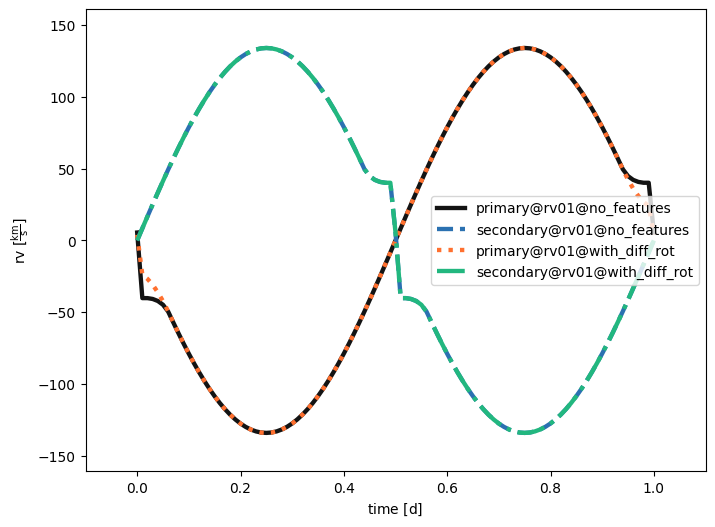

In [5]:
_ = b.plot(kind='rv', show=True, legend=True)